In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import pandas as pd
from tqdm import tqdm
from scipy.optimize import minimize, basinhopping

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [3]:
Main.eval('using Distributed')
Main.eval('addprocs(1)') 

array([2], dtype=int64)

Choose NP strong coupling prescription

In [5]:
Main.eval("""      
    df_LO = readdlm("fixed order/EECLO.csv", ',')
    df_NLO = readdlm("fixed order/EECNLO.csv", ',')
    df_NNLO = readdlm("fixed order/EECNNLO.csv", ',')
            
""")

Main.include("strong coupling\\constants.jl")
Main.include("strong coupling\\alpha_s.jl")

Main.include("fixed order\\perturbative EEC.jl")
Main.include("fixed order\\SCET.jl")
Main.include("fixed order\\non-singular.jl")
Main.include("fixed order\\analytic.jl")

Main.include("cross section.jl")
Main.include("NP.jl")

Main.include("parallel/fit.jl")

JuliaError: Exception 'UndefVarError: `readdlm` not defined' occurred while calling julia code:
      
    df_LO = readdlm("fixed order/EECLO.csv", ',')
    df_NLO = readdlm("fixed order/EECNLO.csv", ',')
    df_NNLO = readdlm("fixed order/EECNNLO.csv", ',')
            


Range Choice

In [20]:
χ_lower = 0
χ_upper = 30
kt_lower = 0
kt_upper = 1000

In [ ]:
I_JLAB2022_pim_C = 1


Read Data

In [ ]:
#-------------------------------------------------------------------
#dataset_names = ["MARKII"]
#-------------------------------------------------------------------
#-------------------------------------------------------------------
dataset_names = ["OPAL","SLD","TOPAZ_595","TOPAZ_533",
                "TASSO_435","TASSO_348","MARKII","MAC"]
#-------------------------------------------------------------------

dataset_qua = ["OPAL","OPAL_new","MAC"]  
 
df_qua = {}

for name in dataset_qua:
    file_path = f"data/{name}.csv"
    df = pd.read_csv(file_path)
    
    χ = df["CHI"]
    EEC = df["EEC"]
    ERROR = df["STAT"]
    
    df1 = pd.DataFrame({"CHI": χ, "EEC": EEC, "ERROR": ERROR})
    df_qua[name] = df1

dataset_ss = ["SLD","DELPHI","TOPAZ_595","TOPAZ_533","TASSO_435","TASSO_348","TASSO_220","TASSO_140","MARKII"]

df_ss = {}

for name in dataset_ss:
    file_path = f"data/{name}.csv"
    df = pd.read_csv(file_path)
    
    χ = df["CHI"]
    EEC = df["EEC"]
    ERROR = np.sqrt(df["STAT"]**2+df["SYS"]**2)
    
    df1 = pd.DataFrame({"CHI": χ, "EEC": EEC, "ERROR": ERROR})
    df_ss[name] = df1

df = df_qua
df.update(df_ss)

df_truncated = {}
χ = {}
EEC = {}
ERROR = {}

for name in dataset_names:
    kt_list = np.sqrt((1-np.cos(df[name]["CHI"]*np.pi/180))/2)*Q_list[name]
    df_truncated[name] = df[name][(kt_list <= kt_upper) & (kt_list >= kt_lower) & 
                                  (df[name]["CHI"] <= χ_upper) & (df[name]["CHI"] >= χ_lower)]
    
    χ[name] = np.array(df_truncated[name]["CHI"])
    EEC[name] = np.array(df_truncated[name]["EEC"])
    ERROR[name] = np.array(df_truncated[name]["ERROR"])

In [22]:
display(df_truncated)
for name in dataset_names:
    display(len(df_truncated[name]))

{'OPAL':      CHI    EEC  ERROR
 0    2.7  1.300  0.030
 1    4.5  1.380  0.030
 2    6.3  1.197  0.016
 3    8.1  0.974  0.017
 4    9.9  0.796  0.019
 5   11.7  0.661  0.019
 6   13.5  0.553  0.016
 7   15.3  0.461  0.011
 8   17.1  0.390  0.011
 9   18.9  0.334  0.011
 10  20.7  0.289  0.010
 11  22.5  0.255  0.011
 12  24.3  0.227  0.009
 13  26.1  0.206  0.007
 14  27.9  0.188  0.007
 15  29.7  0.174  0.007,
 'SLD':     CHI    EEC     ERROR
 0   5.4  1.316  0.032558
 1   9.0  0.874  0.020396
 2  12.6  0.598  0.019235
 3  16.2  0.425  0.011180
 4  19.8  0.310  0.014142
 5  23.4  0.241  0.005099
 6  27.0  0.199  0.005099,
 'TOPAZ_595':     CHI    EEC     ERROR
 0   5.4  1.037  0.049493
 1   9.0  0.850  0.038013
 2  12.6  0.654  0.031198
 3  16.2  0.470  0.022857
 4  19.8  0.397  0.019904
 5  23.4  0.310  0.014757
 6  27.0  0.244  0.013276,
 'TOPAZ_533':     CHI    EEC     ERROR
 0   5.4  0.993  0.045899
 1   9.0  0.839  0.036363
 2  12.6  0.642  0.029740
 3  16.2  0.474  0.021920
 4

16

7

7

7

7

7

7

7

Chi-Square calculation

In [23]:
def DELTA_func(ylist,PRED):

    l = len(ylist)
    theory = np.zeros(l)
    for i in range(l):
        simpson = 1/12*(PRED[0][i] + 4*PRED[1][i] + 2*PRED[2][i] + 4*PRED[3][i] + PRED[4][i])
        theory[i] = np.nan_to_num(simpson,nan=0.0)
    return theory - ylist

#def DELTA_func(ylist,PRED):
#    l = len(ylist)
#    theory = np.zeros(l)
#    for i in range(l):
#        simpson = PRED[0][i] 
#        theory[i] = np.nan_to_num(simpson,nan=0.0)
#    return theory - ylist

def CHI2_func(DELTA,ERROR):
    chi_squared = np.sum(np.square(DELTA/ERROR))
    return chi_squared

Define Objective

In [24]:
import sys
def objective(params, df, Q_list, dataset_names, if_renormalon):

    #----------
    XLL = 2 #1 for NLL
    #----------

    N = 5
    #N = 1
    
    chi2 = 0
    length = 0
    
    αs = params[0]
    params_noαs = params[1:]

    for name in dataset_names:

        xlist={}
        xlist_mid=np.array(df[name]["CHI"])
        binsize=abs(xlist_mid[1]-xlist_mid[0]) # Evenly sized bins assumed
        for i in range(N):
            xlist[i]=xlist_mid-binsize/2+i*binsize/(N-1)

        #xlist={}
        #xlist_mid=np.array(df[name]["CHI"])
        #for i in range(N):
        #    xlist[i]=xlist_mid

        ylist=np.array(df[name]["EEC"])
        ERROR_list=np.array(df[name]["ERROR"])

        l = len(xlist_mid)
        length = length + l

        PRED={}

        if if_renormalon:
            Ω1 = params_noαs[0]
            parameters = params_noαs[1:]
            for quartile in range(N):
                PRED[quartile] = Main.model(xlist=xlist[quartile], αs=αs, Q=Q_list[name], order=XLL, params=parameters, Ω1=Ω1)
            DELTA =  DELTA_func(ylist,PRED)
        else:
            parameters = params_noαs
            for quartile in range(N):
                PRED[quartile] = Main.model(xlist=xlist[quartile], αs=αs, Q=Q_list[name], order=XLL, params=parameters)                
            DELTA =  DELTA_func(ylist,PRED)                       

        chi_square = CHI2_func(DELTA,ERROR_list)
        chi2 = chi2 + chi_square

    return chi2/length

Define minimization related

In [25]:
import csv
import sys

class ProgressCallback:
    def __init__(self, df, Q_list, dataset_names, if_renormalon, csv_file='record.csv'):
        self.df = df
        self.Q_list = Q_list
        self.dataset_names = dataset_names
        self.if_renormalon = if_renormalon
        self.iteration = 0
        self.csv_file = csv_file

        with open(self.csv_file, mode='w', newline='') as file:
            writer = csv.writer(file)
            writer.writerow(["Iteration"] + [f"Param_{i+1}" for i in range(len(Q_list))] + ["Chi2/dof"])

    def __call__(self, params):
        self.iteration += 1
        chi2_bydof = objective(params, self.df, self.Q_list, self.dataset_names, self.if_renormalon)
        
        print(f"Iteration: {self.iteration}, Params: {params}, Chi2/dof: {chi2_bydof}")
        sys.stdout.flush()

        with open(self.csv_file, mode='a', newline='') as file:
            writer = csv.writer(file)
            writer.writerow([self.iteration] + list(params) + [chi2_bydof])


class MyBounds:
    def __init__(self, xmax, xmin):
        self.xmax = np.array(xmax)
        self.xmin = np.array(xmin)

    def __call__(self, **kwargs):
        x = kwargs["x_new"]
        tmax = bool(np.all(x <= self.xmax))
        tmin = bool(np.all(x >= self.xmin))
        return tmax and tmin

Test

In [26]:
objective([0.118, 1.5, 1.5], df_truncated, Q_list, dataset_names, False)

232.0631494909344

In [27]:
if_renormalon = False

Local then hopping

In [28]:
initial_params = [0.118, 2.0, 2.0] #best_params

bounds = [ [0.118 , 0.118], # αs
           [0.0, 100.0], # a1
           [0.0, 100.0], # a1
           #[0.0, 4.0], # a1
           #[0.0, 4.0], # a1
        ]

bounds_T = [list(t) for t in zip(*bounds)]

progress_callback = ProgressCallback(df_truncated, Q_list, dataset_names, if_renormalon)

minimizer_kwargs = {
    "method": "L-BFGS-B",
    "bounds": bounds,
    "args": (df_truncated, Q_list, dataset_names, if_renormalon),
    "options": {'maxiter': 100, 'disp': True, "ftol": 10**(-10)},
    "callback": progress_callback
}

result = basinhopping(
    objective,
    initial_params,
    minimizer_kwargs=minimizer_kwargs,
    niter=0,
    accept_test=MyBounds(xmax=bounds_T[1],xmin=bounds_T[0])
)

optimal_params = result.x
print(f"Optimal parameters: {optimal_params}")


Iteration: 1, Params: [0.118      8.01175069 1.84782351], Chi2/dof: 258.2791790323521
Iteration: 2, Params: [0.118      8.00339634 1.69762437], Chi2/dof: 214.5848543860235
Iteration: 3, Params: [0.118      6.09664299 1.25806448], Chi2/dof: 134.43200282030713
Iteration: 4, Params: [0.118      2.02259875 0.67532322], Chi2/dof: 32.44025973245965
Iteration: 5, Params: [0.118      2.30583063 0.86319934], Chi2/dof: 13.83645042705005
Iteration: 6, Params: [0.118      2.29615009 0.87124135], Chi2/dof: 13.773800485496023
Iteration: 7, Params: [0.118      2.31799471 0.87586846], Chi2/dof: 13.76109834728742
Iteration: 8, Params: [0.118      2.31787358 0.87597097], Chi2/dof: 13.761088289098236
Iteration: 9, Params: [0.118      2.31786886 0.8759724 ], Chi2/dof: 13.76108828547413
Optimal parameters: [0.118      2.31786886 0.8759724 ]


In [59]:
Main.eval('rmprocs(workers())')

<PyCall.jlwrap Task (runnable) @0x0000020cee697840>

Plot

In [ ]:
NLL = 2
χ_low = 5.0
χ_up = 40.0
optimal_params=[0.118, 1.36503326, 18.38945884]

In [20]:
xlist = np.pi/180*np.linspace(1.0, χ_up, 100, endpoint=True)
length=len(xlist)

αs=optimal_params[0]
params_noαs = optimal_params[1:]
print(params_noαs)

v={}
non_singular = {}

for name in dataset_names:
    
    if if_renormalon: 
        Ω1 = params_noαs[0]
        parameters = params_noαs[1:]  
        if len(parameters) > 0:
            v[name] = Main.sigma_fast(Q=Q_list[name], χ_list=xlist, μ_ini=91.2, αs_ini=αs, nf=5, order=NLL, params=parameters, Ω1=Ω1)
        else:
            v[name] = Main.sigma_fast(Q=Q_list[name], χ_list=xlist, μ_ini=91.2, αs_ini=αs, nf=5, order=NLL, Ω1=Ω1)            
    else:
        parameters = params_noαs
        if len(parameters) > 0:
            v[name] = Main.sigma_fast(Q=Q_list[name], χ_list=xlist, μ_ini=91.2, αs_ini=αs, nf=5, order=NLL, params=parameters)
        else:
            v[name] = Main.sigma_fast(Q=Q_list[name], χ_list=xlist, μ_ini=91.2, αs_ini=αs, nf=5, order=NLL)      

    non_singular[name] = []
    for x in xlist:
        non_singular[name].append(Main.non_singular_sigma_χ(χ=x, Q=Q_list[name], μ_ini=91.2, αs_ini=αs, nf=5, order=NLL))

[1.36503326, 18.38945884]


In [21]:
display(xlist,v,non_singular)

array([0.01745329, 0.02432883, 0.03120437, 0.03807991, 0.04495545,
       0.05183099, 0.05870653, 0.06558207, 0.07245761, 0.07933315,
       0.08620869, 0.09308423, 0.09995977, 0.10683531, 0.11371085,
       0.12058638, 0.12746192, 0.13433746, 0.141213  , 0.14808854,
       0.15496408, 0.16183962, 0.16871516, 0.1755907 , 0.18246624,
       0.18934178, 0.19621732, 0.20309286, 0.2099684 , 0.21684394,
       0.22371948, 0.23059502, 0.23747056, 0.2443461 , 0.25122163,
       0.25809717, 0.26497271, 0.27184825, 0.27872379, 0.28559933,
       0.29247487, 0.29935041, 0.30622595, 0.31310149, 0.31997703,
       0.32685257, 0.33372811, 0.34060365, 0.34747919, 0.35435473,
       0.36123027, 0.36810581, 0.37498135, 0.38185688, 0.38873242,
       0.39560796, 0.4024835 , 0.40935904, 0.41623458, 0.42311012,
       0.42998566, 0.4368612 , 0.44373674, 0.45061228, 0.45748782,
       0.46436336, 0.4712389 , 0.47811444, 0.48498998, 0.49186552,
       0.49874106, 0.5056166 , 0.51249213, 0.51936767, 0.52624

{'OPAL': array([2.03926094, 2.33633549, 2.44024581, 2.43057248, 2.35807459,
        2.25251   , 2.13125794, 2.00459203, 1.8786711 , 1.75709658,
        1.64191558, 1.53412815, 1.43412023, 1.34183724, 1.25700982,
        1.17919501, 1.10791049, 1.04261764, 0.98281165, 0.92797948,
        0.87766772, 0.83143121, 0.78888908, 0.74967162, 0.71346925,
        0.67998139, 0.64896046, 0.6201644 , 0.59339649, 0.56846236,
        0.54520577, 0.52347054, 0.50313214, 0.48406475, 0.46616841,
        0.44934151, 0.43350305, 0.41857075, 0.4044782 , 0.39115871,
        0.37855706, 0.36661929, 0.35529867, 0.34455178, 0.33433831,
        0.32462366, 0.31537232, 0.30655717, 0.29814624, 0.29011885,
        0.28244557, 0.27511129, 0.26808837, 0.2613666 , 0.25491953,
        0.24874124, 0.24280607, 0.23711186, 0.23163345, 0.22637193,
        0.22130253, 0.21642908, 0.21172716, 0.20720281, 0.20283211,
        0.19862274, 0.19455148, 0.19062707, 0.18682729, 0.18316133,
        0.1796084 , 0.1761774 , 0.172849

{'OPAL': [76.0266819600964,
  1.5483926113854876,
  0.19777537564478265,
  0.14692468709356732,
  -0.0033390793908281637,
  0.006358025405682288,
  0.0010130430279868565,
  0.0008674396639482662,
  0.0013909484111046758,
  0.0014138730244332809,
  0.0016533800503181404,
  0.001661816742871957,
  0.0017856650710459544,
  0.0019167983979774294,
  0.002026862349046118,
  0.002149465928454053,
  0.002264560798798851,
  0.002382917019008487,
  0.0024984690121825338,
  0.0026149117407874714,
  0.00273118046953264,
  0.0028472931428429097,
  0.0029634319387115047,
  0.0030796238441610866,
  0.0031954715524925496,
  0.0033111815031024836,
  0.0034269101518181145,
  0.003542506269138696,
  0.0036580562574729004,
  0.0037735517808618383,
  0.003888966793225661,
  0.004004346137539773,
  0.004119691070873569,
  0.004235007110855457,
  0.004350308990091007,
  0.004465599889393079,
  0.004580885736674852,
  0.00469617892545844,
  0.004811483721902585,
  0.004926810543662246,
  0.005042162325576347,

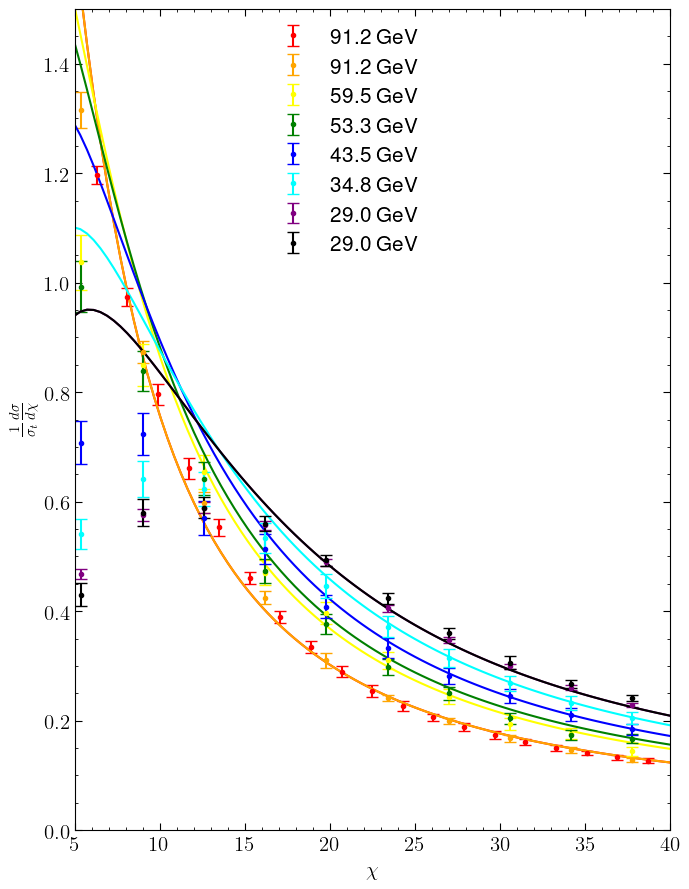

In [22]:
fig, ax1 = plt.subplots(1, 1, figsize=(7, 9)) 

sizeOfFont = 15
sizeOfTick = 15

color = ["red","orange","yellow","green","blue","cyan","purple","black","yellow","orange"]
i=0
for name in dataset_names:
    ax1.errorbar(df[name]["CHI"], df[name]["EEC"], df[name]["ERROR"], fmt='o',label=str(Q_list[name]) + " GeV", color=color[i], capsize=4,markersize=3)
    ax1.plot(xlist*180/np.pi, v[name]+non_singular[name], color=color[i])
    i=i+1

ax1.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_t} \frac{d \sigma}{d \chi}$",fontsize=sizeOfFont)
ax1.legend()

ax1.minorticks_on()
ax1.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax1.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.3, 1))

props = dict(boxstyle='round', facecolor='white', alpha=0)
#ax1.text(0.4, 0.95,  r"\rm $ \mathrm{Q}= 91.2 \mathrm{GeV} $", transform=ax1.transAxes, fontsize=sizeOfFont,
#verticalalignment='top', bbox=props)

plt.ylim(0.0,1.5)
plt.xlim(χ_low,χ_up)

plt.tight_layout()  
plt.show()

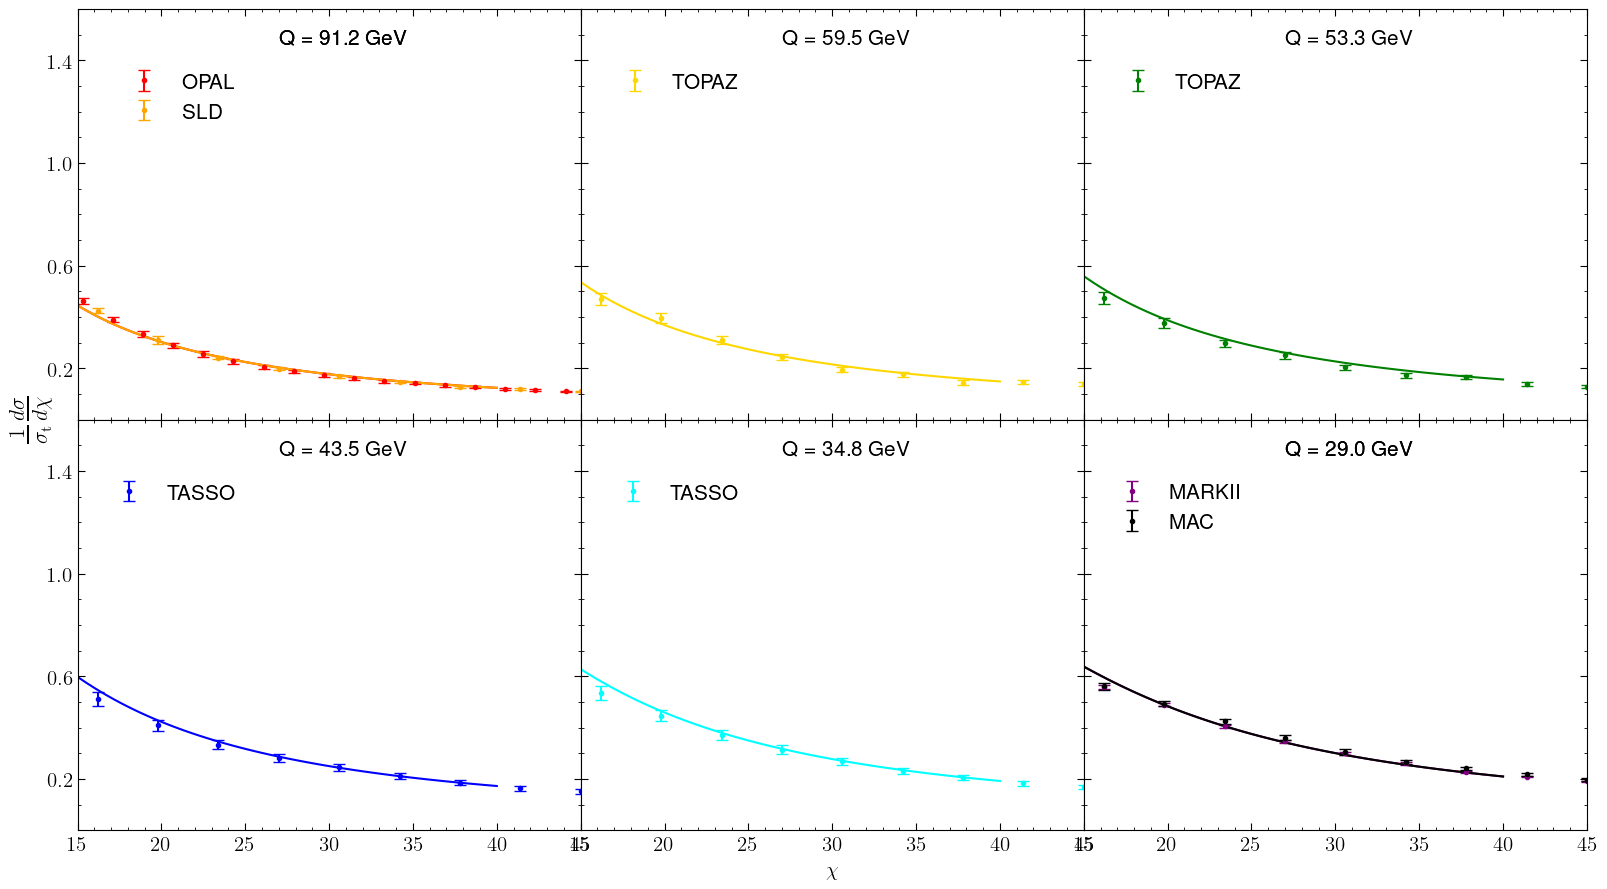

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
ax1, ax2, ax3, ax4, ax5, ax6 = axes.ravel()

sizeOfFont = 15
sizeOfTick = 15

color = ["red","orange","gold","green","blue","cyan","purple","black","yellow","green"]
ax_list = [ax1,ax2,ax3,ax4,ax5,ax6]
Q_set = [91.2,59.5,53.3,43.5,34.8,29.0,22.0,14.0]

name_set = {}
name_set["SLD"]       = "SLD"
name_set["OPAL"]      = "OPAL"
name_set["DELPHI"]    = "DELPHI"
name_set["TOPAZ_595"] = "TOPAZ"
name_set["TOPAZ_533"] = "TOPAZ"
name_set["TASSO_435"] = "TASSO"
name_set["TASSO_348"] = "TASSO"
name_set["MARKII"]    = "MARKII"
name_set["MAC"]       = "MAC"
name_set["TASSO_220"] = "TASSO"
name_set["TASSO_140"] = "TASSO"

i=0
j=0
for Q in Q_set:
    for name in dataset_names:
        if Q_list[name]==Q:
            ax_list[i].errorbar(df[name]["CHI"], df[name]["EEC"], df[name]["ERROR"], fmt='o',label=str(name_set[name]), color=color[j], capsize=4,markersize=3)
            ax_list[i].plot(xlist*180/np.pi, v[name]+non_singular[name], color=color[j])
            ax_list[i].text(0.4, 0.95, "Q = " + str(Q_list[name]) + " GeV", transform=ax_list[i].transAxes, fontsize=sizeOfFont, verticalalignment='top', bbox=props)
            j=j+1
    i=i+1

ax5.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_{\rm{t}}} \frac{d \sigma}{d \chi}$",fontsize=1.5*sizeOfFont)
ax1.yaxis.set_label_coords(-0.05,0.0)
for ax in ax_list:
    ax.legend()
    ax.minorticks_on()
    ax.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
    ax.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
    ax.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.35, 0.89))
    #ax.axvline(x=χ_upper)

props = dict(boxstyle='round', facecolor='white', alpha=0)

plt.ylim(0.0, 1.6)
plt.yticks([0.2,0.6,1.0,1.4])

plt.xlim(15,45)

plt.tight_layout()
plt.subplots_adjust(wspace=0,hspace=0)  
plt.show()

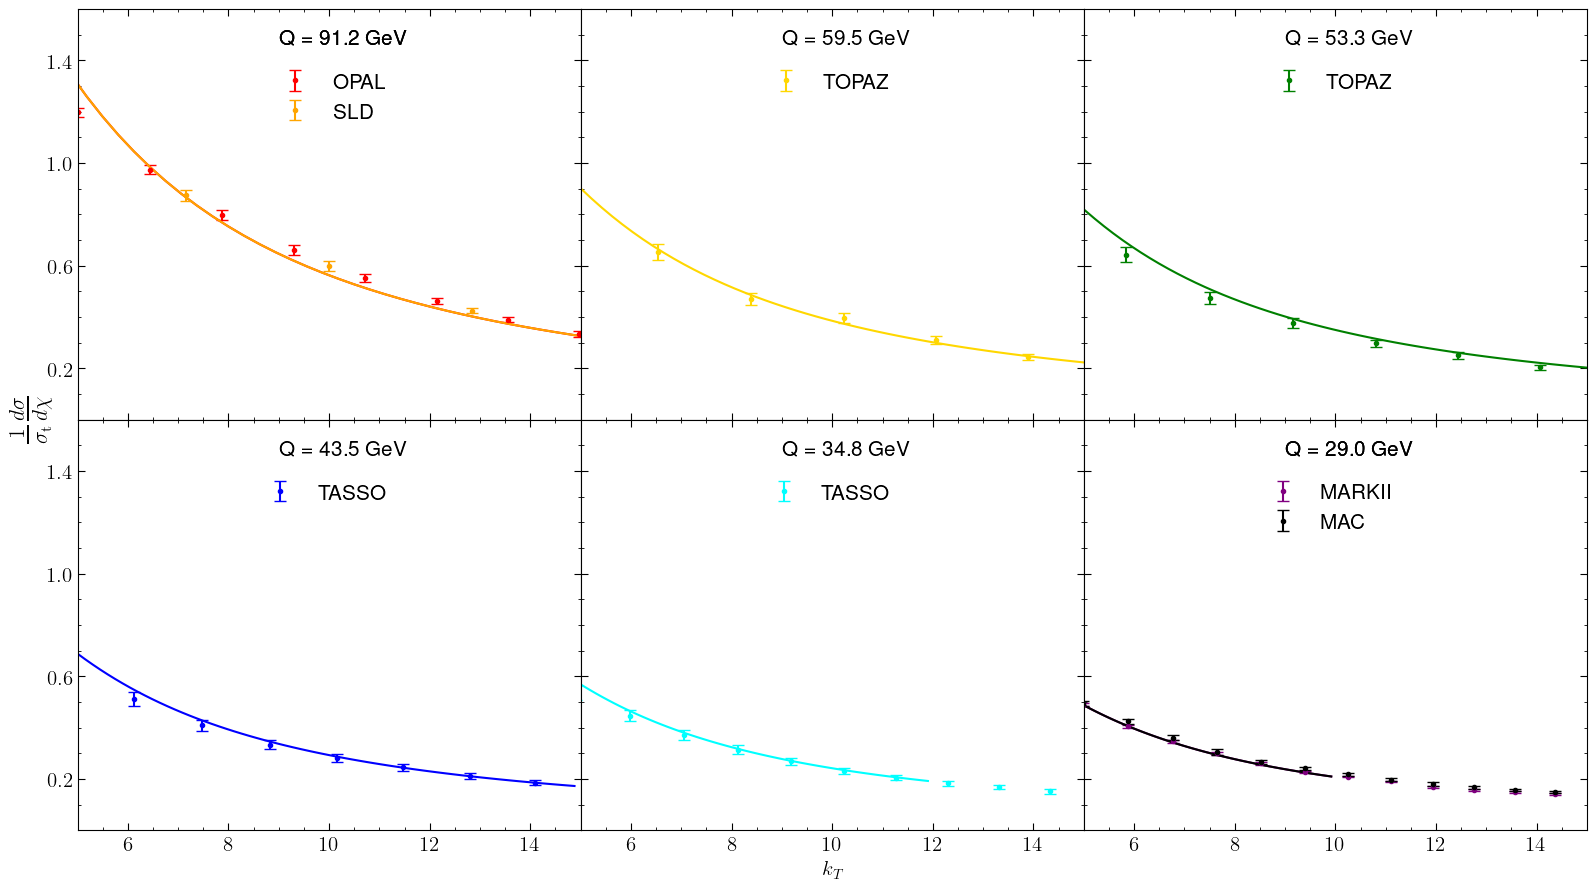

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
ax1, ax2, ax3, ax4, ax5, ax6 = axes.ravel()

sizeOfFont = 15
sizeOfTick = 15

color = ["red","orange","gold","green","blue","cyan","purple","black","yellow","green"]
ax_list = [ax1,ax2,ax3,ax4,ax5,ax6]
Q_set = [91.2,59.5,53.3,43.5,34.8,29.0,22.0,14.0]

name_set = {}
name_set["SLD"]       = "SLD"
name_set["OPAL"]      = "OPAL"
name_set["DELPHI"]    = "DELPHI"
name_set["TOPAZ_595"] = "TOPAZ"
name_set["TOPAZ_533"] = "TOPAZ"
name_set["TASSO_435"] = "TASSO"
name_set["TASSO_348"] = "TASSO"
name_set["MARKII"]    = "MARKII"
name_set["MAC"]       = "MAC"
name_set["TASSO_220"] = "TASSO"
name_set["TASSO_140"] = "TASSO"

i=0
j=0
for Q in Q_set:
    for name in dataset_names:
        if Q_list[name]==Q:
            kt_data = np.sqrt((1-np.cos(df[name]["CHI"]*np.pi/180))/2)*Q_list[name] 
            kt_list = np.sqrt((1-np.cos(xlist))/2)*Q_list[name] 
            ax_list[i].errorbar(kt_data, df[name]["EEC"], df[name]["ERROR"], fmt='o',label=str(name_set[name]), color=color[j], capsize=4,markersize=3)
            ax_list[i].plot(kt_list, v[name]+non_singular[name], color=color[j])
            ax_list[i].text(0.4, 0.95, "Q = " + str(Q_list[name]) + " GeV", transform=ax_list[i].transAxes, fontsize=sizeOfFont, verticalalignment='top', bbox=props)
            j=j+1
    i=i+1

ax5.set_xlabel(r"\rm $k_T$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_{\rm{t}}} \frac{d \sigma}{d \chi}$",fontsize=1.5*sizeOfFont)
ax1.yaxis.set_label_coords(-0.05,0.0)
for ax in ax_list:
    ax.legend()
    ax.minorticks_on()
    ax.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
    ax.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
    ax.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.65, 0.89))
    #ax.axvline(x=χ_upper)

props = dict(boxstyle='round', facecolor='white', alpha=0)

plt.ylim(0.0, 1.6)
plt.yticks([0.2,0.6,1.0,1.4])

plt.xlim(5,15)

plt.tight_layout()
plt.subplots_adjust(wspace=0,hspace=0)  
plt.show()

In [25]:
average_error={}

for name in dataset_names:
    l = len(χ[name])
    average_error[name]=round(np.sum(df_truncated[name]["ERROR"]**2)**0.5/l,4)

display(average_error)

{'OPAL': np.float64(0.0026),
 'SLD': np.float64(0.0039),
 'TOPAZ_595': np.float64(0.0063),
 'TOPAZ_533': np.float64(0.006),
 'TASSO_435': np.float64(0.0066),
 'TASSO_348': np.float64(0.0066),
 'MARKII': np.float64(0.0022),
 'MAC': np.float64(0.0042)}